# Step 2 Part A: Clean, filter, and engineer core features

In [12]:
import pandas as pd

df = pd.read_csv("btc_options_hourly_master.csv")
print(f"Loaded {len(df)} raw rows.")
df.head()

Loaded 892912 raw rows.


,symbol,hour_bucket,timestamp,type,strike_price,expiration,open_interest,bid_price,bid_amount,bid_iv,...,ask_amount,ask_iv,mark_price,mark_iv,underlying_price,delta,gamma,vega,theta,datetime
0,BTC-10JAN20-5750-C,2019-12-31 23:00:00,1577836798404000,call,5750.0,1578643200000000,0.5,0.1990,0.1,NaN,...,3.0,126.07,0.200711,76.53,7180.40,0.96970,0.00008,0.78771,-3.22966,2019-12-31 23:59:58.404
1,BTC-10JAN20-5750-C,2020-01-01 00:00:00,1577840398404000,call,5750.0,1578643200000000,0.5,0.1975,0.1,48.98,...,3.0,130.46,0.199226,76.77,7166.48,0.96849,0.00008,0.81033,-3.34768,2020-01-01 00:59:58.404
2,BTC-10JAN20-5750-C,2020-01-01 01:00:00,1577843998404000,call,5750.0,1578643200000000,0.5,0.2020,0.1,45.29,...,3.0,118.20,0.203535,77.34,7206.37,0.97096,0.00007,0.75970,-3.17613,2020-01-01 01:59:58.404
3,BTC-10JAN20-5750-C,2020-01-01 02:00:00,1577847595134000,call,5750.0,1578643200000000,0.5,0.2045,0.1,51.50,...,3.0,108.79,0.206323,78.43,7231.74,0.97147,0.00007,0.74962,-3.19228,2020-01-01 02:59:55.134
4,BTC-10JAN20-5750-C,2020-01-01 03:00:00,1577851198405000,call,5750.0,1578643200000000,0.5,0.2025,0.1,36.12,...,3.0,116.33,0.204357,78.70,7213.10,0.96996,0.00008,0.77874,-3.34269,2020-01-01 03:59:58.405


In [13]:
# Parse timestamps
df["hour_bucket"] = pd.to_datetime(df["hour_bucket"])
df["expiration_dt"] = pd.to_datetime(df["expiration"], unit="us")
df[["hour_bucket", "expiration_dt"]].head()

,hour_bucket,expiration_dt
0,2019-12-31 23:00:00,2020-01-10 08:00:00
1,2020-01-01 00:00:00,2020-01-10 08:00:00
2,2020-01-01 01:00:00,2020-01-10 08:00:00
3,2020-01-01 02:00:00,2020-01-10 08:00:00
4,2020-01-01 03:00:00,2020-01-10 08:00:00


## Liquidity filter
Keep only rows with a real two-sided market (both bid and ask present). Check how much this actually drops before committing to it.

In [14]:
before = len(df)
df = df.dropna(subset=["bid_price", "ask_price"])
print(f"Dropped {before - len(df)} rows with no two-sided quote ({(before-len(df))/before:.1%}).")
print(f"{len(df)} rows remain.")

Dropped 240715 rows with no two-sided quote (27.0%).
652197 rows remain.


## Feature engineering: time-to-maturity, moneyness, mid-price, spread

In [15]:
df["time_to_maturity_days"] = (df["expiration_dt"] - df["hour_bucket"]).dt.total_seconds() / 86400
df["moneyness"] = df["strike_price"] / df["underlying_price"]
df["mid_price"] = (df["bid_price"] + df["ask_price"]) / 2
df["bid_ask_spread"] = df["ask_price"] - df["bid_price"]
df["relative_spread"] = df["bid_ask_spread"] / df["mid_price"]

df[["symbol", "time_to_maturity_days", "moneyness", "mid_price", "relative_spread"]].describe()

,time_to_maturity_days,moneyness,mid_price,relative_spread
count,652197.000000,652197.000000,652197.000000,652197.000000
mean,86.653896,1.115162,0.168326,0.239327
std,99.513537,0.747540,0.434594,0.400327
min,0.000000,0.079457,0.000100,-1.200000
25%,11.333333,0.799639,0.008750,0.034286
50%,53.541667,0.992730,0.052500,0.077519
75%,143.916667,1.190527,0.193000,0.224309
max,364.375000,15.676627,11.536750,1.999973


Look at the `.describe()` output above -- do the ranges look sane? `moneyness` should mostly cluster around 1.0, `time_to_maturity_days` should be positive and not absurdly large, `relative_spread` should be a small positive fraction (not huge).

## Sanity checks: drop obviously broken rows

In [16]:
before = len(df)
df = df[df["time_to_maturity_days"] > 0]
df = df[df["strike_price"] > 0]
df = df[df["underlying_price"] > 0]
df = df[df["bid_ask_spread"] >= 0]
print(f"Dropped {before - len(df)} broken rows. {len(df)} remain.")

Dropped 320 broken rows. 651877 remain.


## Quick visual sanity check
Distribution of moneyness and relative spread -- worth a quick look before trusting this dataset for anything downstream.

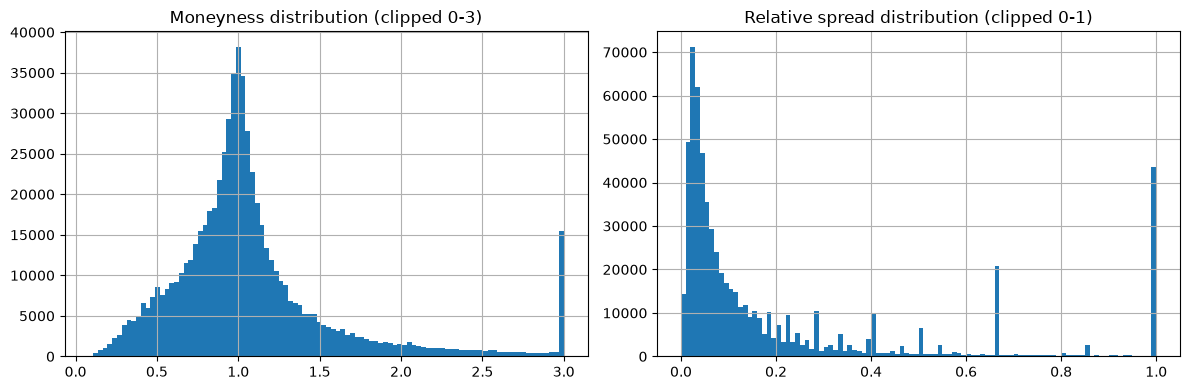

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["moneyness"].clip(0, 3).hist(bins=100, ax=axes[0])
axes[0].set_title("Moneyness distribution (clipped 0-3)")

df["relative_spread"].clip(0, 1).hist(bins=100, ax=axes[1])
axes[1].set_title("Relative spread distribution (clipped 0-1)")
plt.tight_layout()
plt.show()

## Rows per year -- make sure no year got gutted by filtering

In [18]:
df["hour_bucket"].dt.year.value_counts().sort_index()

hour_bucket
2019       196
2020     78531
2021     91578
2022     94044
2023    150186
2024    237342
Name: count, dtype: int64

## Moneyness range filter
The moneyness histogram showed a pile-up at the 3.0 clip boundary, and the spread histogram showed tick-size quantization artifacts on cheap, deep OTM contracts. Restrict to a moneyness band where hedging activity is realistically concentrated.

In [19]:
before = len(df)
df = df[(df["moneyness"] >= 0.5) & (df["moneyness"] <= 2.0)]
print(f"Dropped {before - len(df)} rows outside 0.5-2.0 moneyness ({(before-len(df))/before:.1%}).")
print(f"{len(df)} rows remain.")

Dropped 91781 rows outside 0.5-2.0 moneyness (14.1%).
560096 rows remain.


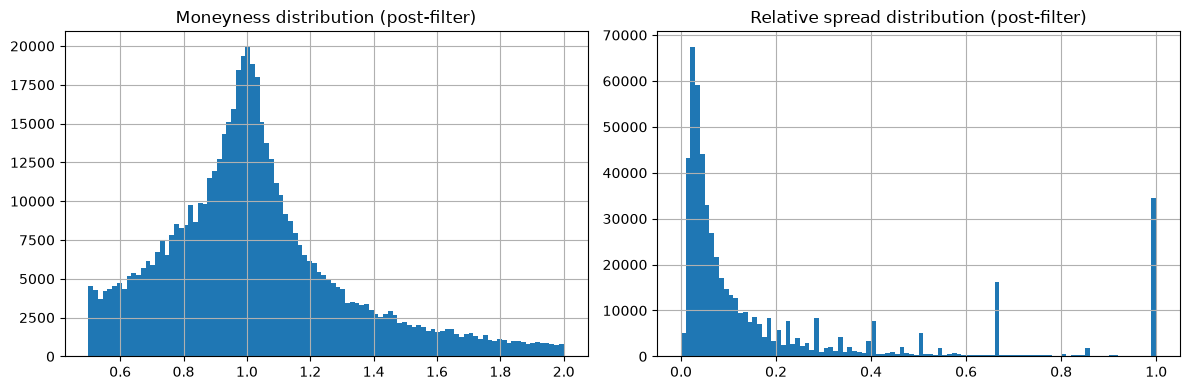

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["moneyness"].hist(bins=100, ax=axes[0])
axes[0].set_title("Moneyness distribution (post-filter)")

df["relative_spread"].clip(0, 1).hist(bins=100, ax=axes[1])
axes[1].set_title("Relative spread distribution (post-filter)")
plt.tight_layout()
plt.show()

In [21]:
df["hour_bucket"].dt.year.value_counts().sort_index()

hour_bucket
2019       154
2020     67368
2021     71918
2022     80840
2023    133354
2024    206462
Name: count, dtype: int64

## Relative spread cap
The tick-size artifact spikes (at 0.67, 1.0) persisted after the moneyness filter -- they come from cheap option prices in general (far OTM strikes AND short-dated near-money options), not moneyness specifically. Cap relative spread directly: a quote this wide is not a reliable tradeable price regardless of cause.

In [22]:
before = len(df)
df = df[df["relative_spread"] <= 0.5]
print(f"Dropped {before - len(df)} rows with relative spread > 50% ({(before-len(df))/before:.1%}).")
print(f"{len(df)} rows remain.")

Dropped 69767 rows with relative spread > 50% (12.5%).
490329 rows remain.


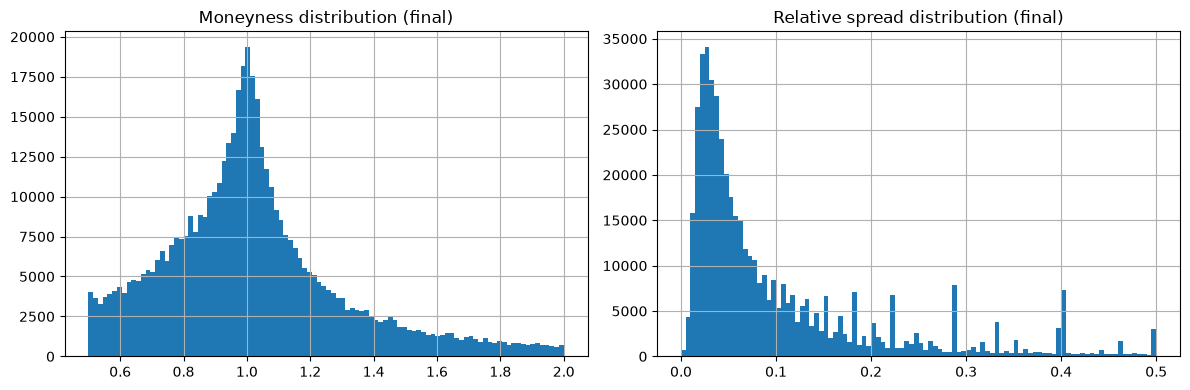

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["moneyness"].hist(bins=100, ax=axes[0])
axes[0].set_title("Moneyness distribution (final)")

df["relative_spread"].hist(bins=100, ax=axes[1])
axes[1].set_title("Relative spread distribution (final)")
plt.tight_layout()
plt.show()

In [24]:
df["hour_bucket"].dt.year.value_counts().sort_index()

hour_bucket
2019       138
2020     57066
2021     62414
2022     68343
2023    112487
2024    189881
Name: count, dtype: int64

## Save the cleaned dataset

In [25]:
df.to_csv("btc_options_cleaned.csv", index=False)
print(f"Saved {len(df)} rows to btc_options_cleaned.csv")

Saved 490329 rows to btc_options_cleaned.csv
